In [12]:
import os
import warnings

# Set environment variable to disable oneDNN custom operations
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Suppress cuFFT, cuDNN, and cuBLAS warnings
warnings.filterwarnings('ignore', category=UserWarning, message=".*cuFFT.*")
warnings.filterwarnings('ignore', category=UserWarning, message=".*cuDNN.*")
warnings.filterwarnings('ignore', category=UserWarning, message=".*cuBLAS.*")

# Set TensorFlow log level to suppress info messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [13]:
# Import Libraries
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


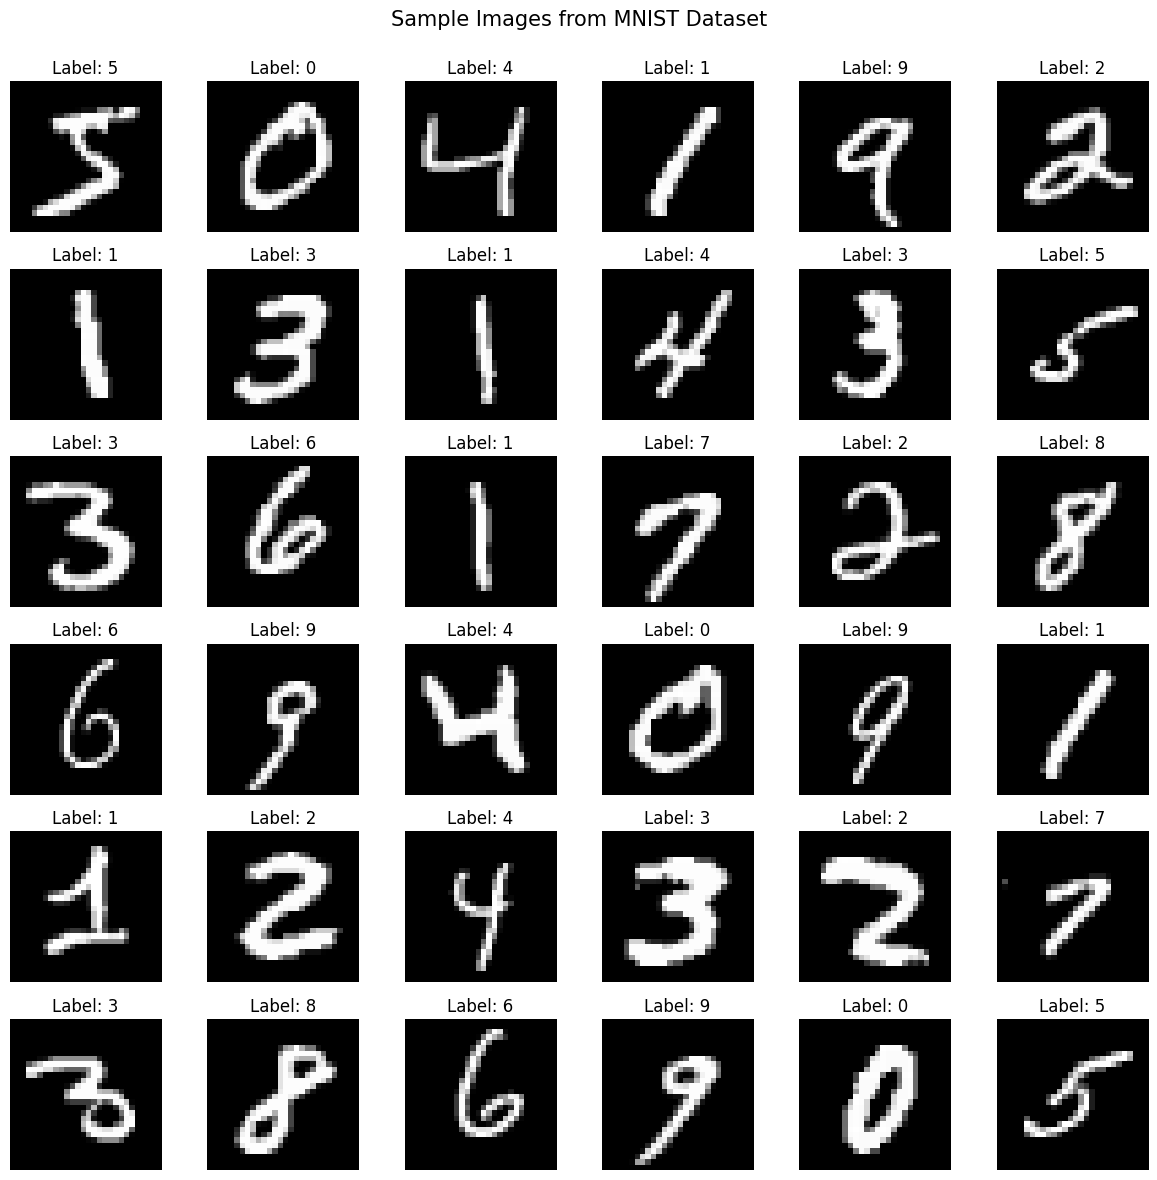

In [14]:
# ===========================================
# 1. Load and Explore Dataset
# ===========================================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Visualize (36 images)
plt.figure(figsize=(12, 12))

# Print out 36 images to see the dataset and labels
for i in range(36):
    plt.subplot(6, 6, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Sample Images from MNIST Dataset", fontsize=15)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [15]:
# ===========================================
# 2. Data Preprocessing
# ===========================================
# Normalize pixel values (this sets the range between 0-1 instead of 0-255)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [16]:
# ===========================================
# 3. Build the Neural Network Model
# ===========================================
model = Sequential([
    Flatten(input_shape=(28, 28)),             # Input layer
    Dense(128, activation='relu'),             # Hidden layer 1 (ReLU)
    Dropout(0.2),
    Dense(64, activation='relu'),              # Hidden layer 2 (ReLU)
    Dropout(0.2),
    Dense(10, activation='softmax')            # Output layer (softmax)
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ===========================================
# 4. Train the Model
# ===========================================
history = model.fit(X_train, y_train_cat,
                    validation_split=0.1,
                    epochs=10,
                    batch_size=128,
                    verbose=2)

Epoch 1/10
422/422 - 2s - 4ms/step - accuracy: 0.8535 - loss: 0.4871 - val_accuracy: 0.9610 - val_loss: 0.1436
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.9386 - loss: 0.2097 - val_accuracy: 0.9712 - val_loss: 0.1017
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.9530 - loss: 0.1578 - val_accuracy: 0.9722 - val_loss: 0.0895
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.9613 - loss: 0.1309 - val_accuracy: 0.9757 - val_loss: 0.0891
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.9655 - loss: 0.1128 - val_accuracy: 0.9773 - val_loss: 0.0766
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.9701 - loss: 0.0986 - val_accuracy: 0.9792 - val_loss: 0.0732
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.9733 - loss: 0.0885 - val_accuracy: 0.9765 - val_loss: 0.0748
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.9752 - loss: 0.0783 - val_accuracy: 0.9802 - val_loss: 0.0673
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.9770 - loss: 0.0727 - val_accuracy: 0.9813 - val_loss: 0.0671
E


Test Accuracy: 0.9801


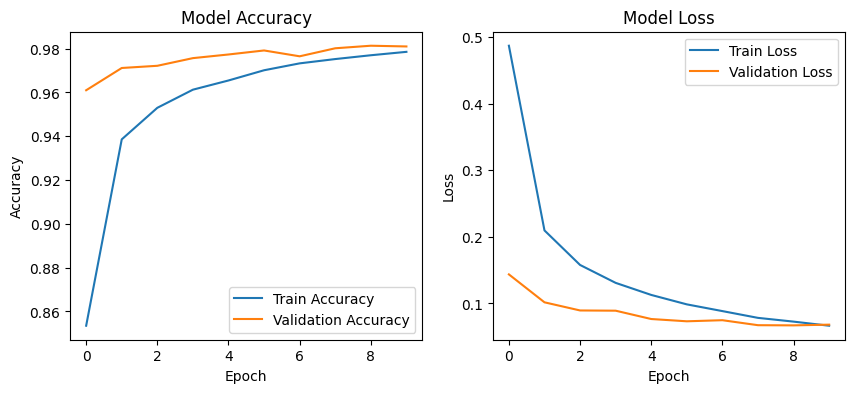

In [18]:
# ===========================================
# 5. Evaluate Model Performance
# ===========================================
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot model accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot model loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step


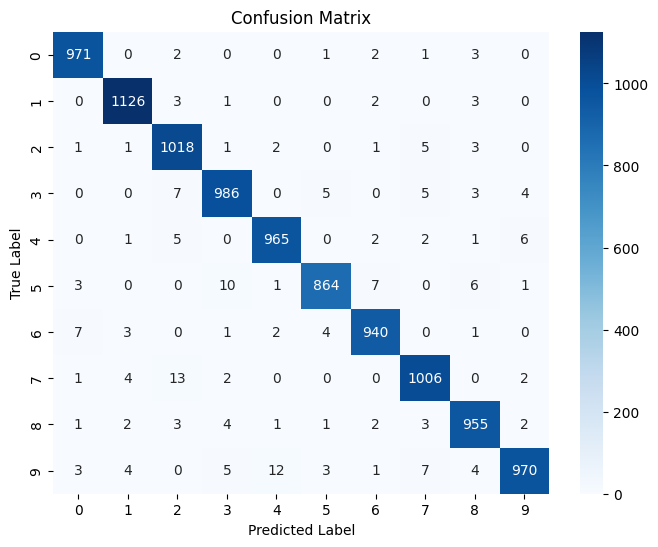


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [19]:
# ===========================================
# 6. Confusion Matrix & Classification Report
# ===========================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))

# Create the matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

In [20]:
# ===========================================
# 7. Save Model (Native Keras Format)
# ===========================================
model.save("mnist_digit_classifier.keras")
print("Model has been saved as mnist_digit_classifier.keras")

Model has been saved as mnist_digit_classifier.keras


In [21]:
# ===========================================
# 8. Load Model to Verify
# ===========================================
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_digit_classifier.keras")
print("Model has loaded successfully!")

# Evaluate the loaded model to confirm it works
test_loss, test_acc = loaded_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nLoaded Model Test Accuracy: {test_acc:.4f}")

Model has loaded successfully!

Loaded Model Test Accuracy: 0.9801


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


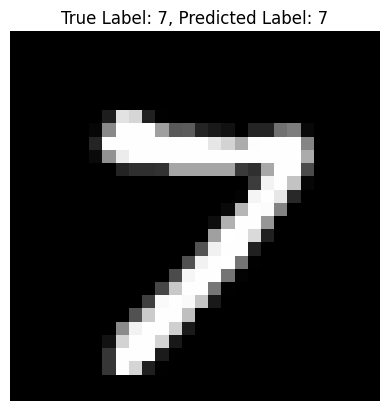


True Label: 7
Predicted Label: 7
Prediction is correct!


In [22]:
# ===========================================
# 9. Test with a Random Image
# ===========================================

# Select a random index from the test set
random_index = random.randint(0, len(X_test)-1)

# Get the image and label
random_image = X_test[random_index]
true_label = y_test[random_index]

# Reshape image to (1,28,28)
random_image = random_image.reshape(1, 28, 28)

# Predict the label using the trained model
predicted_probs = model.predict(random_image)
predicted_label = np.argmax(predicted_probs)

# Visualize the image, reshape image again due to it being visualized
plt.imshow(random_image.reshape(28, 28), cmap='gray')
plt.title(f"True Label: {true_label}, Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()

# Print out the prediction result alongside whether or not prediction was correct
print(f"\nTrue Label: {true_label}")
print(f"Predicted Label: {predicted_label}")

if true_label == predicted_label:
    print("Prediction is correct!")
else:
    print("Prediction is incorrect.")